--- Generating Comparison Chart: Observed vs Scenarios vs LSTM vs SARIMA ---


Success! Comparison chart with SARIMA saved at: ..\figuras\figure-hindcasting-validation-monthly-with-lstm-sarima.pdf


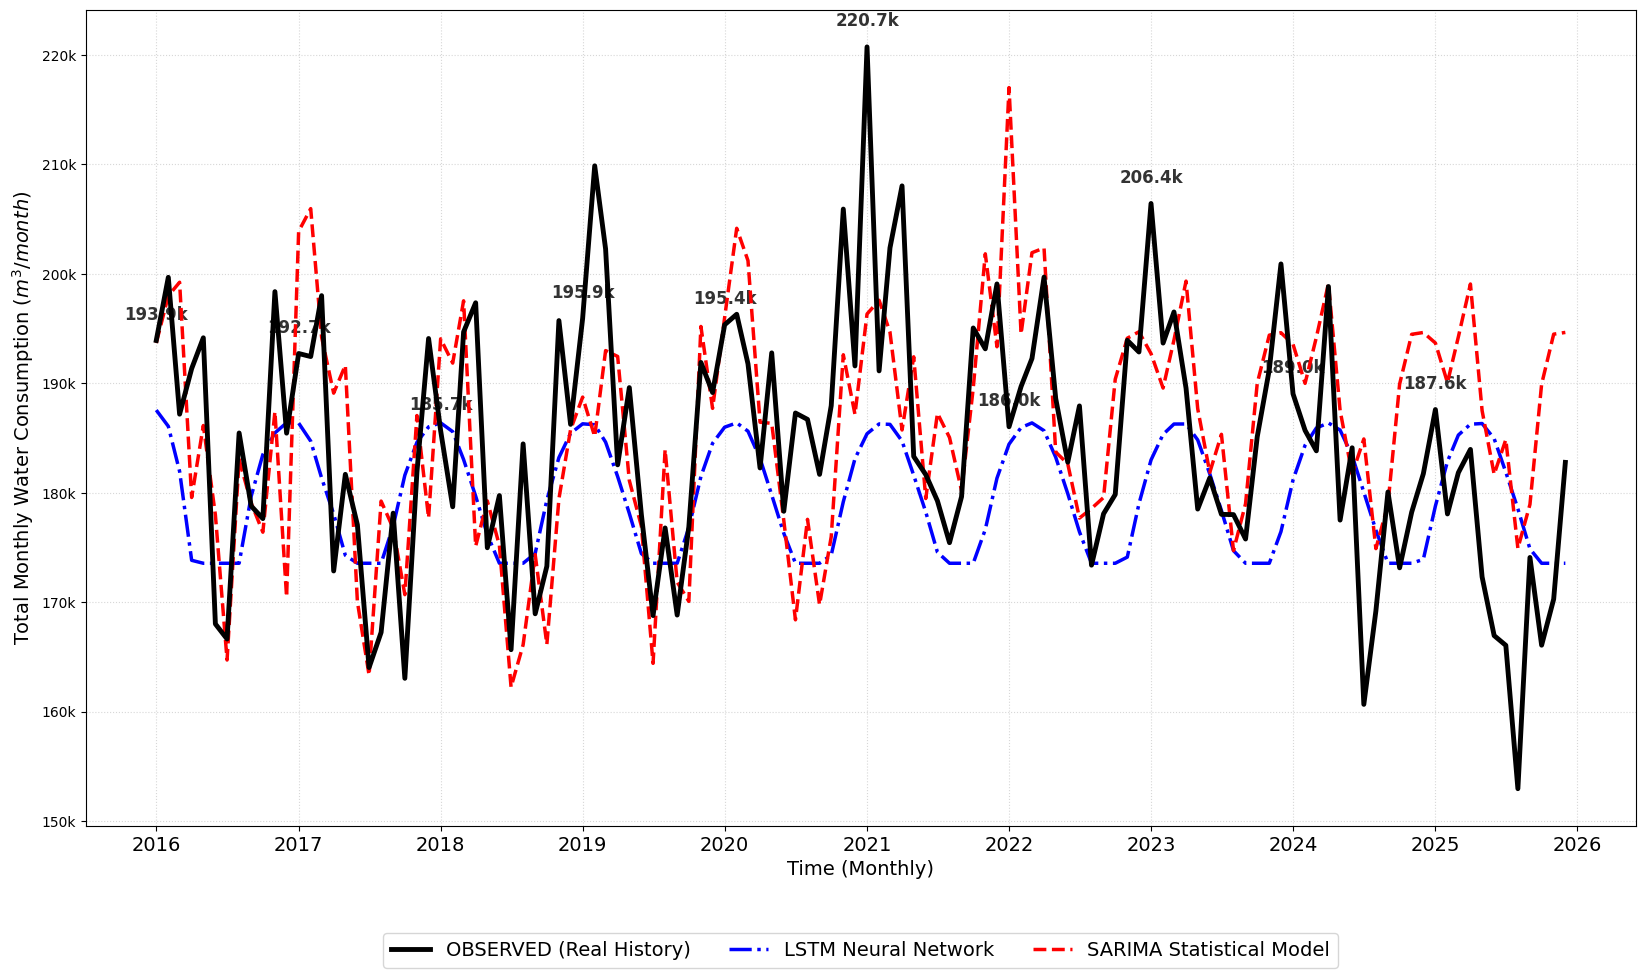

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import numpy as np
import os

# ==========================================
# 1. Configurations and Paths
# ==========================================
BASE_PATH = '..' 

# Input Filenames
REAL_FILE = 'Tabela_consumo_real_historico_2016_2025.csv'
SIM_FILE = 'simulacao_hindcasting_2016_2025.csv'
LSTM_FILE = 'previsao_consumo_2016_2025.csv' 
SARIMA_FILE = 'previsao_consumo_sarima_2016_2025.csv' # File generated in the previous step

# Output Configuration
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')
OUTPUT_FIG = 'figure-hindcasting-validation-monthly-with-lstm-sarima.pdf'

# Search Directories
INPUT_DIR_INCLUDES = os.path.join(BASE_PATH, 'includes')
INPUT_DIR_RESULTS = os.path.join(BASE_PATH, 'resultados')
INPUT_DIR_IA = os.path.join(BASE_PATH, 'modelos IA')

def main():
    print("--- Generating Comparison Chart: Observed vs Scenarios vs LSTM vs SARIMA ---")

    # ==========================================
    # 2. Data Loading and Preparation
    # ==========================================
    
    # A. Load Real Historical Data
    path_real = os.path.join(INPUT_DIR_INCLUDES, REAL_FILE)
    df_real = pd.read_csv(path_real, sep=';', decimal='.')
    df_real['Date'] = pd.to_datetime(df_real['AM_REFERENCIA'].astype(str) + '01', format='%Y%m%d')
    df_real.rename(columns={'real_total_consumption': 'Real'}, inplace=True)

    # B. Load Simulation Results (ABM Scenarios)
    path_sim = os.path.join(INPUT_DIR_RESULTS, SIM_FILE)
    df_sim = pd.read_csv(path_sim, sep=';', decimal=',')
    if 'Ano' in df_sim.columns and 'Mes' in df_sim.columns:
        df_sim['Date'] = pd.to_datetime(df_sim['Ano'].astype(str) + '-' + df_sim['Mes'].astype(str) + '-01')
    
    scenario_cols = [c for c in df_sim.columns if c not in ['Mes', 'Ano', 'Mes_Ano', 'Date', 'AM_REFERENCIA']]

    # C. Load LSTM Prediction Results
    path_lstm = os.path.join(INPUT_DIR_IA, LSTM_FILE) 
    if os.path.exists(path_lstm):
        df_lstm = pd.read_csv(path_lstm, sep=';')
        df_lstm['Date'] = pd.to_datetime(df_lstm['Mes_Referencia'])
    else:
        print(f"Warning: File {LSTM_FILE} not found.")
        df_lstm = None

    # D. Load SARIMA Prediction Results
    path_sarima = os.path.join(INPUT_DIR_IA, SARIMA_FILE)
    if os.path.exists(path_sarima):
        df_sarima = pd.read_csv(path_sarima)
        df_sarima['Date'] = pd.to_datetime(df_sarima['Date'])
    else:
        print(f"Warning: File {SARIMA_FILE} not found.")
        df_sarima = None

    # ==========================================
    # 3. Plotting
    # ==========================================
    fig, ax = plt.subplots(figsize=(20, 12))

    # --- A. Plotting 18 ABM Scenarios ---
    #colors = plt.cm.tab20(np.linspace(0, 1, len(scenario_cols)))
    #for idx, col in enumerate(scenario_cols):
    #    scen_id = col.split('_')[0]
    #    ax.plot(df_sim['Date'], df_sim[col], color=colors[idx],
    #            linestyle='-', linewidth=0.8, alpha=0.3, label=f"ABM {scen_id}")

    # --- B. Plotting LSTM Prediction ---
    if df_lstm is not None:
        ax.plot(df_lstm['Date'], df_lstm['Previsao_Consumo'], label='LSTM Neural Network', 
                color='blue', linestyle='-.', linewidth=2.5, zorder=25)

    # --- C. Plotting SARIMA Prediction ---
    if df_sarima is not None:
        ax.plot(df_sarima['Date'], df_sarima['Projected_Consumption'], label='SARIMA Statistical Model', 
                color='red', linestyle='--', linewidth=2.5, zorder=26)

    # --- D. Plotting Historical Ground Truth (Highlighted) ---
    ax.plot(df_real['Date'], df_real['Real'], label='OBSERVED (Real History)', color='black',
            linestyle='-', linewidth=3.5, zorder=30)

    # Annotations for Historical Data
    df_real_jan = df_real[df_real['Date'].dt.month == 1]
    for _, row in df_real_jan.iterrows():
        ax.annotate(f"{row['Real']/1000:.1f}k", (row['Date'], row['Real']), 
                    xytext=(0, 15), textcoords="offset points",
                    ha='center', fontsize=12, fontweight='bold', color='black', alpha=0.8)

    # ==========================================
    # 4. Final Formatting
    # ==========================================
    ax.set_ylabel('Total Monthly Water Consumption ($m^3/month$)', fontsize=14)
    ax.set_xlabel('Time (Monthly)', fontsize=14)
    
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xticks(rotation=0, fontsize=14)
    
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
    
    plt.grid(True, linestyle=':', alpha=0.5)

    #plt.title('Monthly Hindcasting Comparison: Observed vs. ABM vs. LSTM vs. SARIMA (2016-2025)', 
    #          fontsize=18, fontweight='bold', pad=25)

    # Legend adjust with specific order
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    
    # Priority keys for clarity
    main_keys = ['OBSERVED (Real History)', 'LSTM Neural Network', 'SARIMA Statistical Model']
    other_keys = [k for k in by_label.keys() if k not in main_keys]
    sorted_keys = main_keys + other_keys

    plt.legend([by_label[k] for k in sorted_keys], sorted_keys, 
               loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=5, 
               fontsize=14, frameon=True)
    
    plt.subplots_adjust(bottom=0.20)

    # Save to PDF
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    save_path = os.path.join(OUTPUT_DIR, OUTPUT_FIG)
    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    
    print(f"Success! Comparison chart with SARIMA saved at: {save_path}")
    plt.show()

if __name__ == "__main__":
    main()